# PJM Load Forecasting by Hour-of-Day Experts

This notebook creates 24 separate datasets by hour of day, trains one version of each model per hour, merges the timestamped predictions back together, and then evaluates the merged model families.

## Setup

The notebook reuses the helper functions from `experiments/load_forecasting_by_hour.py` so the notebook and script stay synchronized.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from experiments.load_forecasting_by_hour import (
    HOUR_QRC_TEST,
    HOUR_QRC_TRAIN,
    HOUR_WASHOUT,
    HOURS,
    OUT_DIR,
    fit_full_hourly_classical,
    fit_hourly_experts,
    prepare_hourly_dataframe,
    print_table,
    save_hourly_plots,
)

plt.style.use('seaborn-v0_8-whitegrid')
len(HOURS)

24

## Build the 24 Hourly Datasets

In [2]:
train, test, feature_cols = prepare_hourly_dataframe()
print(f'Train rows: {len(train):,}')
print(f'Test rows:  {len(test):,}')
print(f'Hour buckets: {len(HOURS)}')
print(f'Per-hour QRC window: {HOUR_QRC_TRAIN} train / {HOUR_QRC_TEST} test / washout {HOUR_WASHOUT}')

Train rows: 140,062
Test rows:  5,136
Hour buckets: 24
Per-hour QRC window: 1000 train / 180 test / washout 24


## Full-Year Classical Experts by Hour

In [3]:
full_merged, full_results = fit_full_hourly_classical(train, test, feature_cols)
print_table(full_results, 'Classical by-hour experts - full 2018 test set')
full_results


  Classical by-hour experts - full 2018 test set
  Model                        |  RMSE (MW) |   MAE (MW) |  MAPE (%) |   NRMSE
  --------------------------------------------------------------------------
  Ridge (full by hour)         |     2892.9 |     2182.0 |      6.76 |   0.461
  Random Forest (full by hour) |     2845.0 |     2105.5 |      6.52 |   0.453
  MLP (full by hour)           |     2898.4 |     2178.1 |      6.72 |   0.462
  GAM-like (full by hour)      |     2730.7 |     2038.7 |      6.31 |   0.435


[{'name': 'Ridge (full by hour)',
  'RMSE (MW)': 2892.8734966388784,
  'MAE (MW)': 2182.0029517012804,
  'MAPE (%)': 6.760981332707333,
  'NRMSE': 0.46070532102277234},
 {'name': 'Random Forest (full by hour)',
  'RMSE (MW)': 2844.9723779344854,
  'MAE (MW)': 2105.5259328699603,
  'MAPE (%)': 6.516009091554525,
  'NRMSE': 0.4530768159064243},
 {'name': 'MLP (full by hour)',
  'RMSE (MW)': 2898.3829510236806,
  'MAE (MW)': 2178.066350681659,
  'MAPE (%)': 6.722235160626076,
  'NRMSE': 0.46158273061360294},
 {'name': 'GAM-like (full by hour)',
  'RMSE (MW)': 2730.738170925829,
  'MAE (MW)': 2038.6785770491545,
  'MAPE (%)': 6.312767059310256,
  'NRMSE': 0.43488441756171553}]

## Matched By-Hour Classical vs QRC Comparison

In [4]:
merged, sub_results, timings = fit_hourly_experts(train, test, feature_cols)
print_table(sub_results, 'By-hour experts - matched classical vs QRC comparison')
timings

c:\Users\moham\OneDrive\Documents\New project\qrc-engine\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(



Training QRC models...


c:\Users\moham\OneDrive\Documents\New project\qrc-engine\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(



Training QRC models...


c:\Users\moham\OneDrive\Documents\New project\qrc-engine\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


...

c:\Users\moham\OneDrive\Documents\New project\qrc-engine\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(



Training QRC models...


c:\Users\moham\OneDrive\Documents\New project\qrc-engine\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(



Training QRC models...

  By-hour experts - matched classical vs QRC comparison
  Model                        |  RMSE (MW) |   MAE (MW) |  MAPE (%) |   NRMSE
  --------------------------------------------------------------------------
  Ridge                        |     2602.6 |     1926.7 |      6.32 |   0.531
  Random Forest                |     2570.4 |     1840.1 |      6.04 |   0.524
  MLP                          |     2849.9 |     2099.9 |      6.81 |   0.581
  GAM-like                     |     2404.5 |     1713.7 |      5.60 |   0.490
  QRC Qiskit (ridge)           |     3866.1 |     2951.1 |      9.83 |   0.788
  QRC Qiskit (RF readout)      |     3007.9 |     2222.8 |      7.33 |   0.613
  QRC Dynamiqs                 |     3599.8 |     2765.6 |      9.01 |   0.734
  QRC Perceval Fock+FB         |     3546.3 |     2670.8 |      8.56 |   0.723


{'QRC Qiskit (ridge)': 75.53995759994723,
 'QRC Qiskit (RF readout)': 88.69216210010927,
 'QRC Dynamiqs': 9.293064399855211,
 'QRC Perceval Fock+FB': 238.120034100255}

## Save and Preview the Same Plot Family Again

In [5]:
save_hourly_plots(merged, sub_results, full_results)
sorted(str(path.name) for path in OUT_DIR.glob('load_forecast_by_hour_*'))

['load_forecast_by_hour_comparison.pdf',
 'load_forecast_by_hour_comparison.png',
 'load_forecast_by_hour_full_context.pdf',
 'load_forecast_by_hour_full_context.png',
 'load_forecast_by_hour_rmse.pdf',
 'load_forecast_by_hour_rmse.png']

## Quick Visual Check

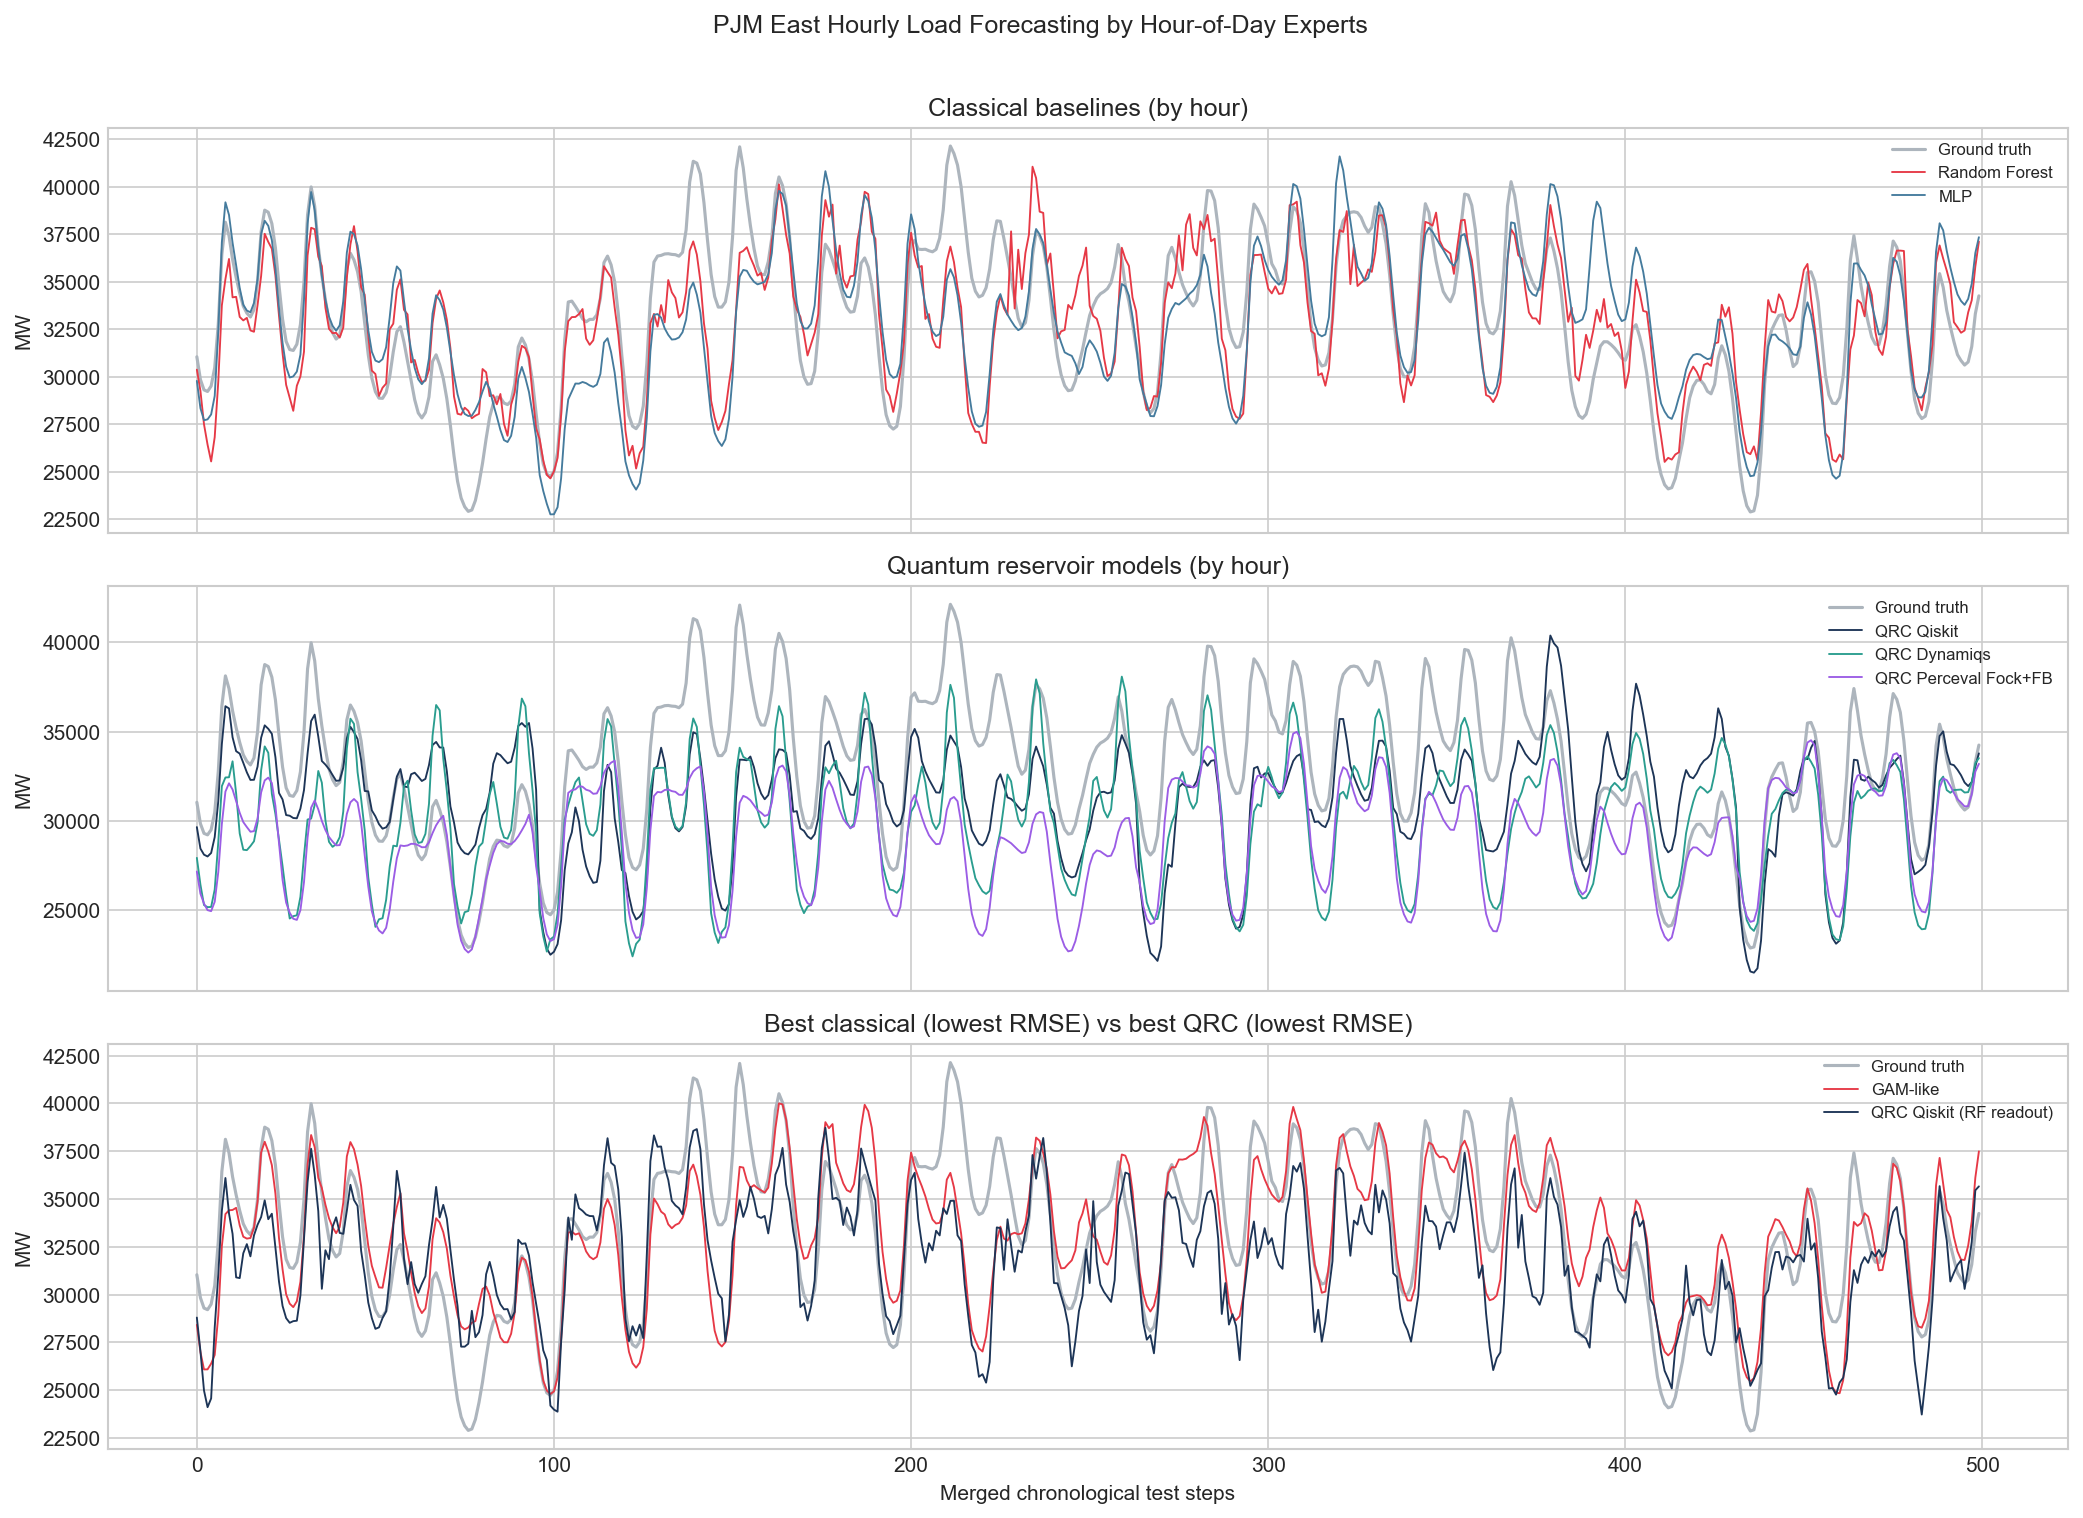

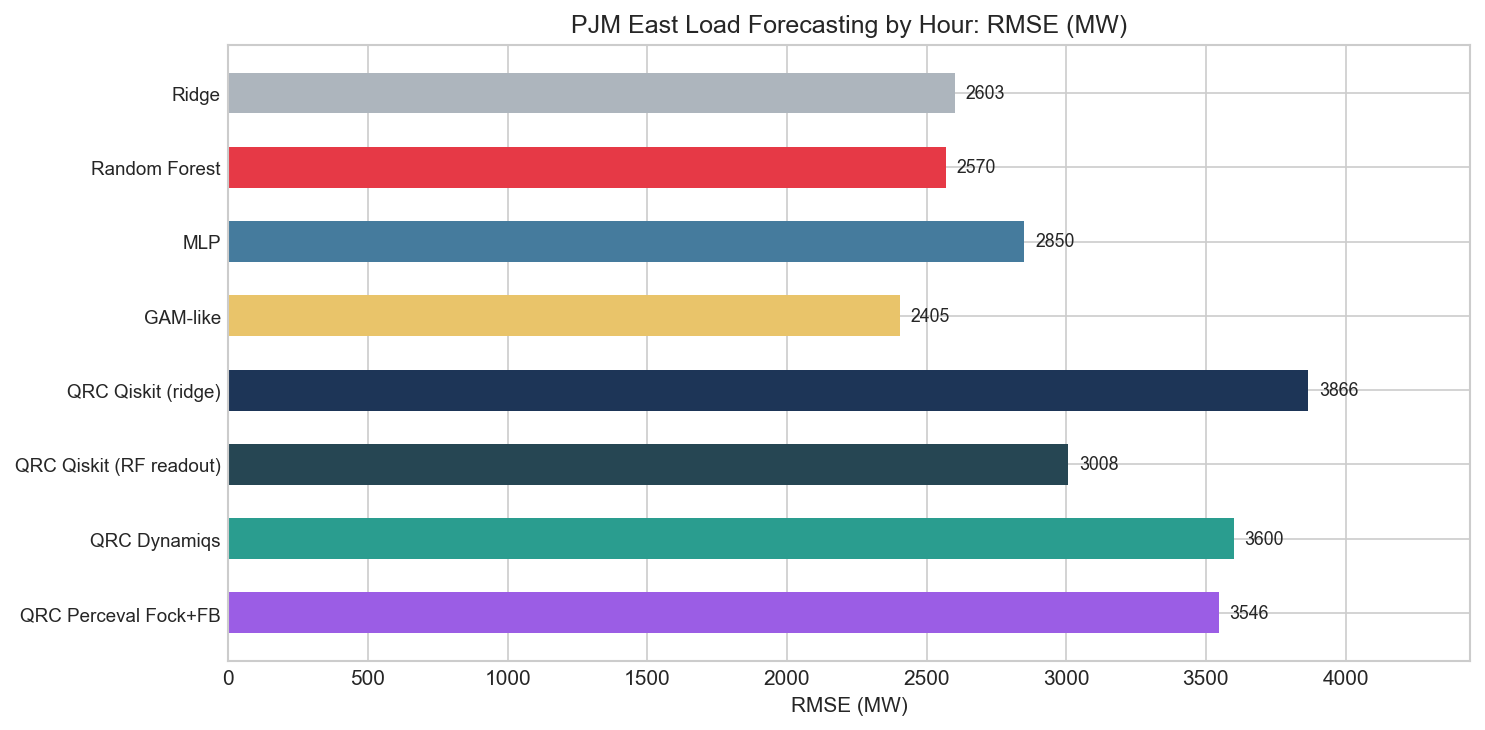

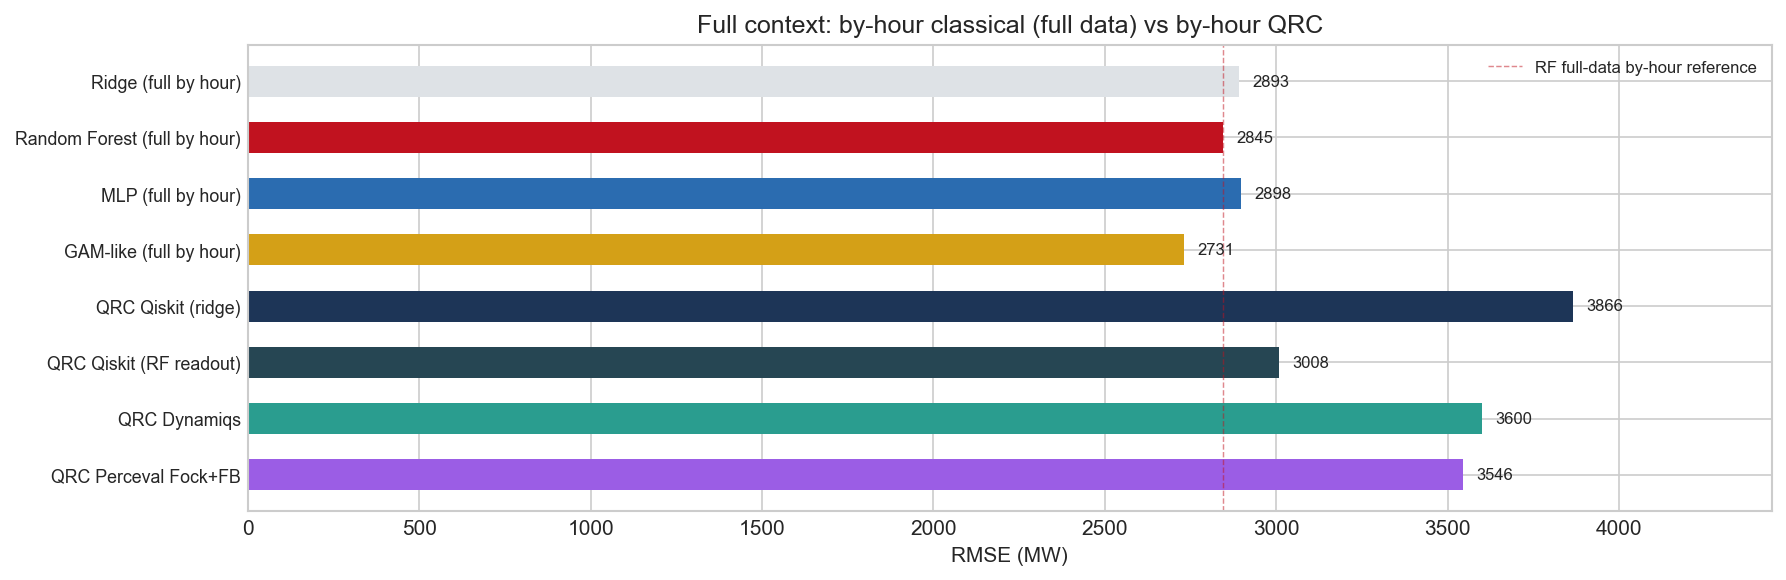

In [6]:
from IPython.display import Image, display

for name in [
    'load_forecast_by_hour_comparison.png',
    'load_forecast_by_hour_rmse.png',
    'load_forecast_by_hour_full_context.png',
]:
    display(Image(filename=str(OUT_DIR / name)))

## Notes

- Each hour of day gets its own expert model family.
- Predictions are merged back in chronological order before computing the final metrics.
- The resulting plots are directly comparable to the original single-model-family experiment.